### Midterm-Denis Pščolka


In [2]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import io
import requests

In [3]:

duk = pd.read_csv("DUK.csv")
sjm = pd.read_csv("SJM.csv")
udr = pd.read_csv("UDR.csv")
wec = pd.read_csv("WEC.csv")


In [4]:
duk

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-01-04,76.102,76.392,73.963,74.386,2683700,0.0,0.0
1,2021-01-05,74.452,74.784,73.830,74.419,2547400,0.0,0.0
2,2021-01-06,74.585,76.094,74.518,75.381,2823000,0.0,0.0
3,2021-01-07,75.580,75.837,74.411,74.535,2989500,0.0,0.0
4,2021-01-08,74.585,74.958,74.145,74.668,2752100,0.0,0.0
...,...,...,...,...,...,...,...,...
999,2024-12-23,105.243,105.759,104.318,105.681,2757400,0.0,0.0
1000,2024-12-24,105.516,106.139,105.243,106.080,991900,0.0,0.0
1001,2024-12-26,105.798,106.061,105.010,105.438,2914600,0.0,0.0
1002,2024-12-27,104.747,106.110,104.649,105.467,2127200,0.0,0.0


In [5]:
companies = {"duk": duk, "sjm": sjm, "udr" : udr, "wec" : wec}

In [6]:
for df in companies.values():
    df["Date"] = pd.to_datetime(df["Date"])
    print(df.Date.dtypes)

datetime64[ns]
datetime64[ns]
datetime64[ns]
datetime64[ns]


In [75]:
#1
for firm, df in companies.items():
    if sum(df["High"] == df["Low"]) == df.shape[0]:
            print(f"the company {firm} has no difference between High and Low price")
        

In [76]:
# there is no such company

In [15]:
for firm, df in companies.items():
    print(f"the highest recorded price for company {firm} is {df['High'].max()}")
    print(f"the lowest recorded price for company {firm} is {df['Low'].min()}")

the highest recorded price for company duk is 116.92
the lowest recorded price for company duk is 71.683
the highest recorded price for company sjm is 148.02
the lowest recorded price for company sjm is 94.635
the highest recorded price for company udr is 52.107
the lowest recorded price for company udr is 28.403
the highest recorded price for company wec is 100.206
the lowest recorded price for company wec is 69.241


In [25]:
#3

for firm, df in companies.items():
    df["LogReturns"] = np.log(df["Close"]) - np.log(df["Close"].shift(1))
    print(f"for company {firm} the min Log Return is {df['LogReturns'].min()}")
    print(f"for company {firm} the max Log Return is {df['LogReturns'].max()}")
    print(f"for company {firm} the mean Log Return is {np.mean(df['LogReturns'])}")
    print(f"for company {firm} the median Log Return is {np.std(df['LogReturns'])}")
    #print(f"for company {firm} the median Log Return is {np.skew(df['LogReturns'])}")

for company duk the min Log Return is -0.048123461300396464
for company duk the max Log Return is 0.038312330615354995
for company duk the mean Log Return is 0.00034227433127468796
for company duk the median Log Return is 0.011463395424137011
for company sjm the min Log Return is -0.1108703867707117
for company sjm the max Log Return is 0.05561666092786677
for company sjm the mean Log Return is 7.41524291156252e-05
for company sjm the median Log Return is 0.013810309680101546
for company udr the min Log Return is -0.062339336411985524
for company udr the max Log Return is 0.08004503535796781
for company udr the mean Log Return is 0.00030183477557424237
for company udr the median Log Return is 0.01456070988429662
for company wec the min Log Return is -0.045642805399610076
for company wec the max Log Return is 0.04929000753878654
for company wec the mean Log Return is 0.00017472763030515617
for company wec the median Log Return is 0.012576168899354256


In [26]:
for company, subdf in companies.items():
    max_row = subdf.loc[subdf["LogReturns"].idxmax()]
    min_row = subdf.loc[subdf["LogReturns"].idxmin()]

    print(f"{company}:")
    print("  Highest log return:", max_row["LogReturns"], "on", max_row["Date"].date())
    print("  Lowest log return:", min_row["LogReturns"], "on", min_row["Date"].date())
    print()

duk:
  Highest log return: 0.038312330615354995 on 2022-11-10
  Lowest log return: -0.048123461300396464 on 2022-02-10

sjm:
  Highest log return: 0.05561666092786677 on 2022-06-07
  Lowest log return: -0.1108703867707117 on 2022-05-18

udr:
  Highest log return: 0.08004503535796781 on 2022-11-10
  Lowest log return: -0.062339336411985524 on 2023-10-27

wec:
  Highest log return: 0.04929000753878654 on 2022-11-10
  Lowest log return: -0.045642805399610076 on 2022-10-06



In [28]:
for firm, df in companies.items():
    df = df.copy()  
    
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date")
    
    weekly_volume = df["Volume"].resample("W").sum()
    avgweekmed = weekly_volume.median()
    
    print(f"the median calendar weekly volume for {firm} was {avgweekmed}")


the median calendar weekly volume for duk was 13899900.0
the median calendar weekly volume for sjm was 4440300.0
the median calendar weekly volume for udr was 9749900.0
the median calendar weekly volume for wec was 6990300.0


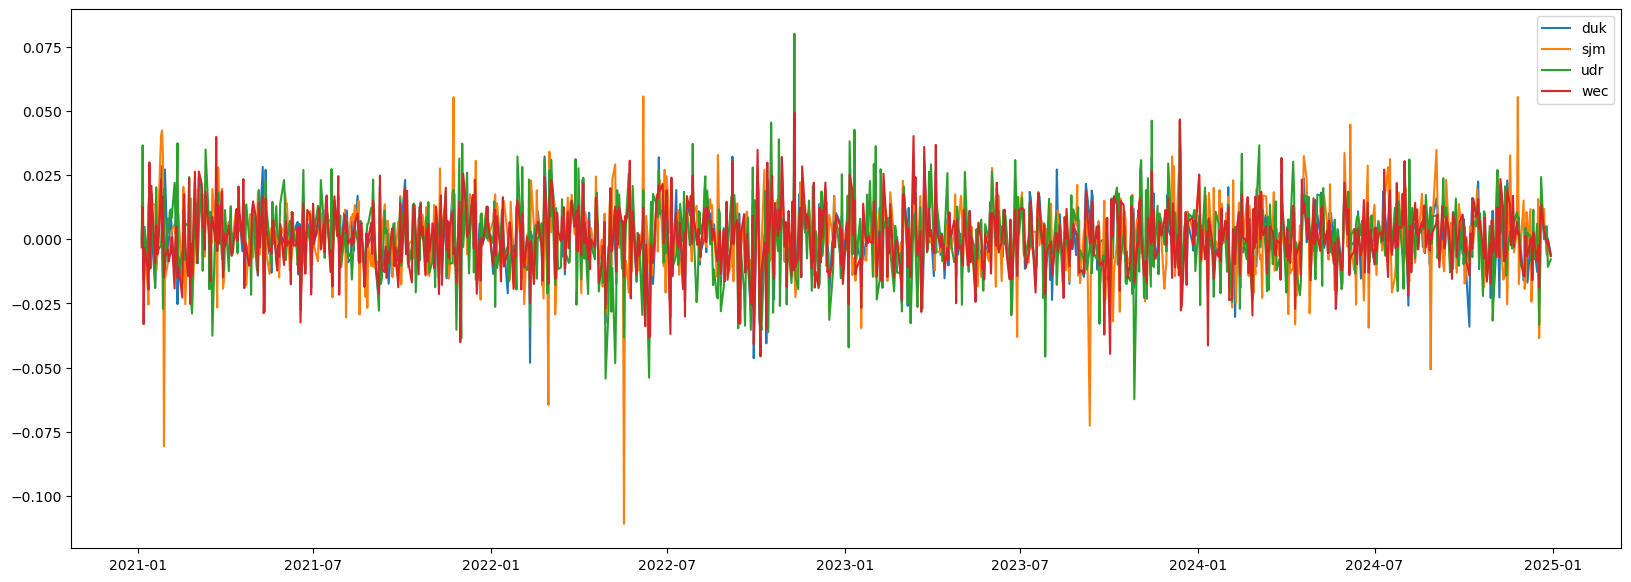

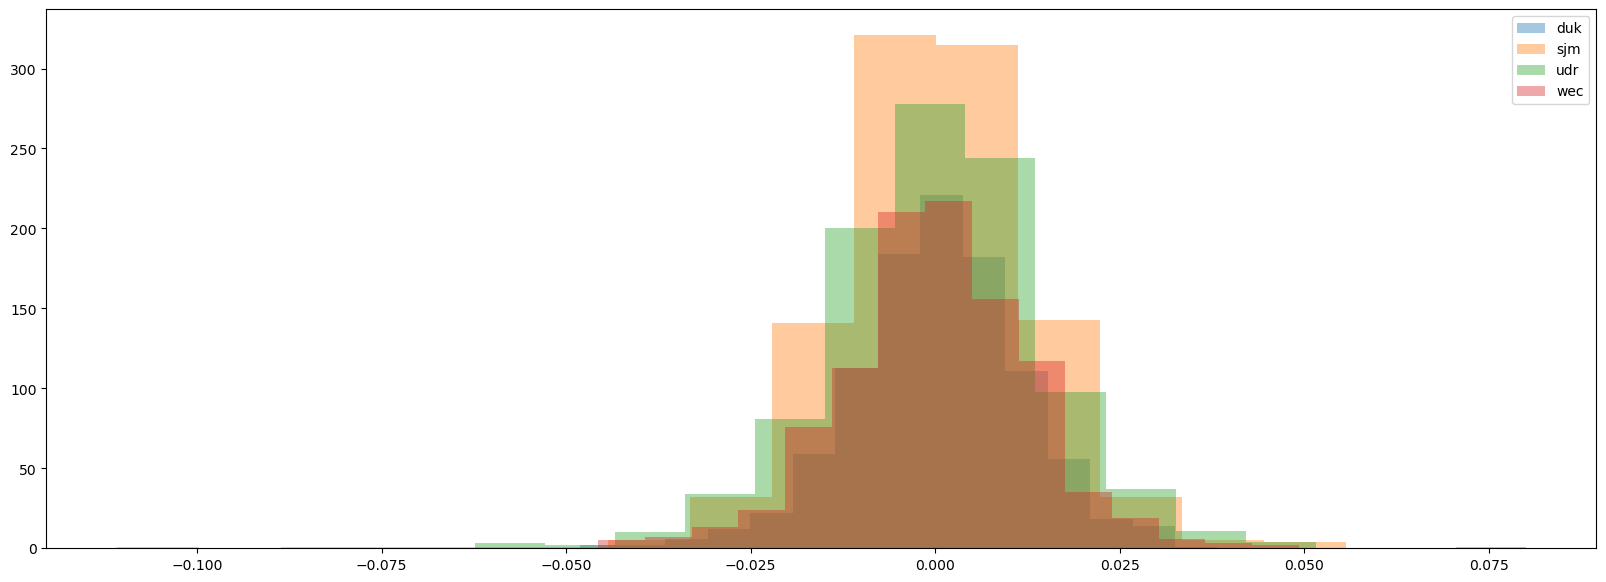

In [39]:
plt.subplots(1,1, figsize = (20,7))
for firm, df in companies.items():
    plt.plot(df["Date"],df["LogReturns"], label = firm)
plt.legend()

#8
plt.subplots(1,1, figsize = (20,7))
for firm, df in companies.items():
    plt.hist(df["LogReturns"], label = firm, bins= 15, alpha = 0.4)
plt.legend()

In [43]:
#2

data = pd.read_csv("companies_no_subindustry.csv")

In [44]:
data.head()

,Symbol,Security,GICS_Sector,hq,included,Founded
0,MMM,3M,Industrials,"Saint Paul, Minnesota",09.08.1976,1902
1,AOS,A. O. Smith,Industrials,"Milwaukee, Wisconsin",26.07.2017,1916
2,ABT,Abbott,Health Care,"North Chicago, Illinois",31.03.1964,1888
3,ABBV,AbbVie,Health Care,"North Chicago, Illinois",31.12.2012,2013 (1888)
4,ABMD,Abiomed,Health Care,"Danvers, Massachusetts",31.05.2018,1981


In [45]:
notfilledin = data["included"].isnull().sum()
print(f"{notfilledin} companies didn't fill in the date of inclusion")

45 companies didn't fill in the date of inclusion


In [48]:
data = data.dropna(subset="included")
today = datetime.datetime.today()
year = today.year
oldest = data.loc[data["Founded"] == data["Founded"].max(), "Symbol"]
youngest = data.loc[data["Founded"] == data["Founded"].min(), "Symbol"]
print(f"the oldest company's symbol is {oldest[oldest.index[0]]}")
print(f"the yongest company's symbol is {youngest[youngest.index[0]]}")
data["f"] = data["Founded"].apply(lambda x: x.split()[0])
data["founded"] = data["f"].apply(lambda x: x.split("/")[0])
data["founded"] = data["founded"].apply(lambda x: int(x))
data["age"] = year - data["founded"]
print(f"the average age of companies is {round(data['age'].mean(),2)} years")


the oldest company's symbol is WBD
the yongest company's symbol is BK
the average age of companies is 68.76 years


(array([], dtype=float64), [])

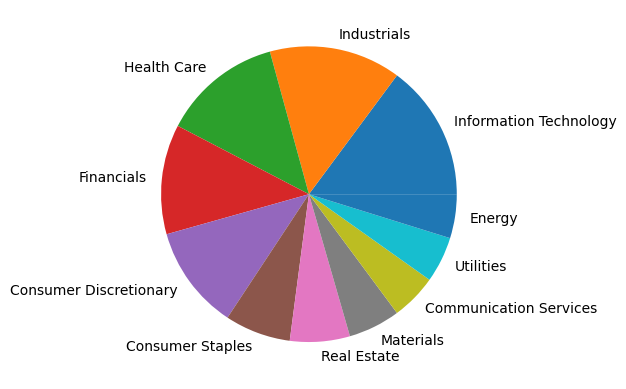

In [49]:
sector = data["GICS_Sector"].value_counts().reset_index()
plt.pie(sector["count"], labels= sector["GICS_Sector"])
plt.xticks(rotation = 90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48],
 [Text(0, 0, ' California'),
  Text(1, 0, ' New York'),
  Text(2, 0, ' Texas'),
  Text(3, 0, ' Illinois'),
  Text(4, 0, ' Pennsylvania'),
  Text(5, 0, ' Massachusetts'),
  Text(6, 0, ' Ohio'),
  Text(7, 0, ' North Carolina'),
  Text(8, 0, ' Georgia'),
  Text(9, 0, ' New Jersey'),
  Text(10, 0, ' Virginia'),
  Text(11, 0, ' Florida'),
  Text(12, 0, ' Minnesota'),
  Text(13, 0, ' Connecticut'),
  Text(14, 0, ' Washington'),
  Text(15, 0, ' Michigan'),
  Text(16, 0, ' Ireland'),
  Text(17, 0, ' Colorado'),
  Text(18, 0, ' Tennessee'),
  Text(19, 0, ' Missouri'),
  Text(20, 0, ' Wisconsin'),
  Text(21, 0, ' Indiana'),
  Text(22, 0, ' Arizona'),
  Text(23, 0, ' Maryland'),
  Text(24, 0, ' United Kingdom'),
  Te

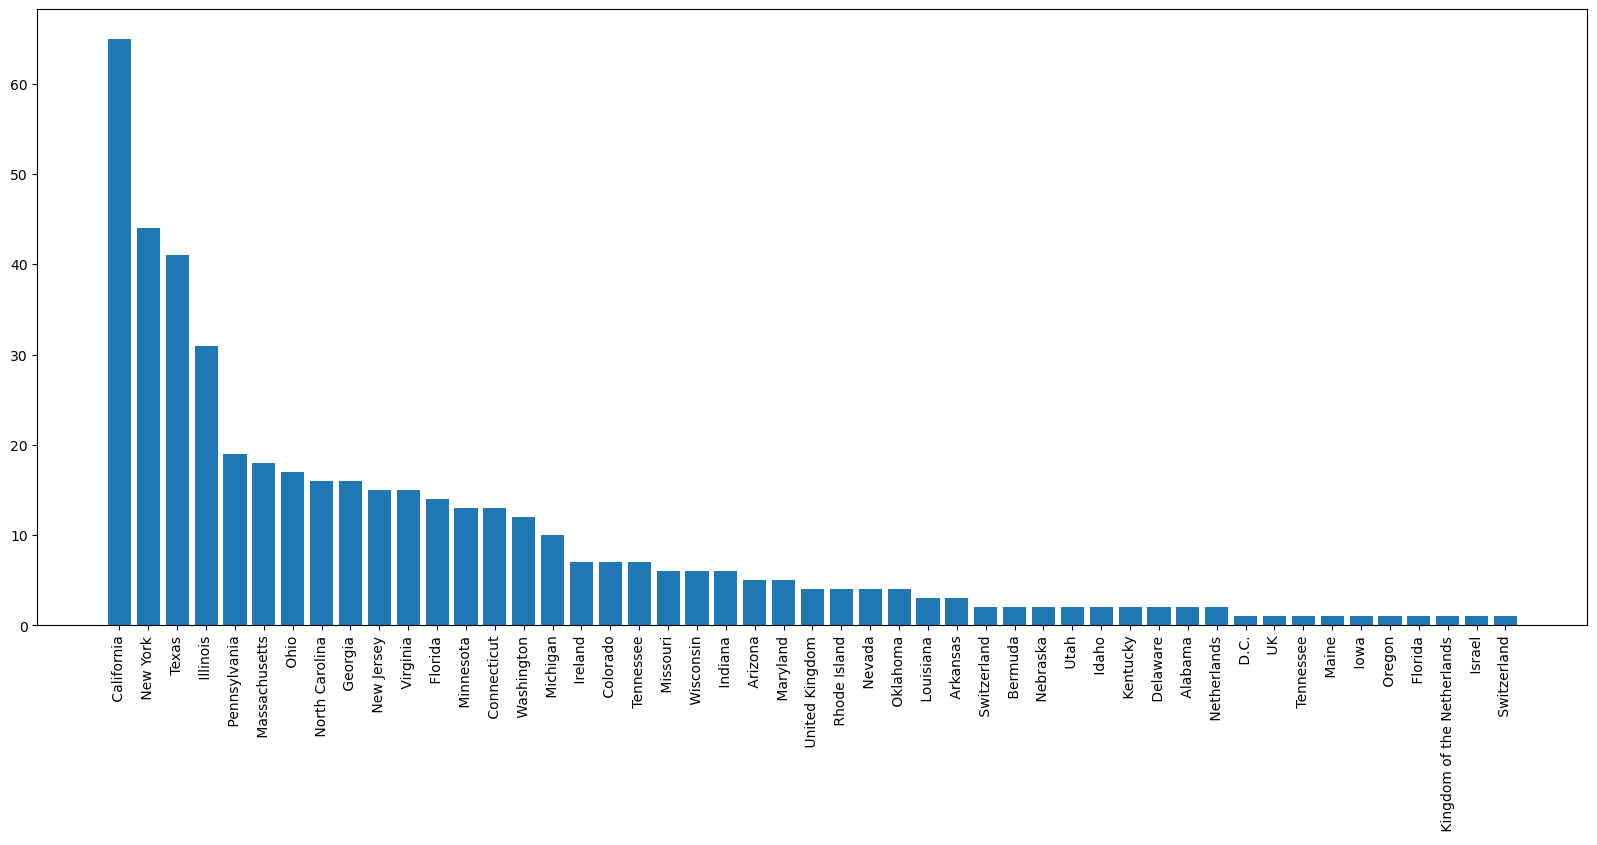

In [51]:
data["state"] = data["hq"].apply(lambda x: x.split(",")[-1])
states = data["state"].value_counts().reset_index()
plt.subplots(1,1, figsize = (20,8))
plt.bar(states["state"], states["count"])
plt.xticks(rotation = 90)

In [52]:
states

,state,count
0,California,65
1,New York,44
2,Texas,41
3,Illinois,31
4,Pennsylvania,19
5,Massachusetts,18
6,Ohio,17
7,North Carolina,16
8,Georgia,16
9,New Jersey,15


In [53]:
data1 = pd.read_csv("companies_subindustry.csv")

In [54]:
data1

,Symbol,subindustry
0,MMM,Industrial Conglomerates
1,AOS,Building Products
2,ABT,Health Care Equipment
3,ABBV,Pharmaceuticals
4,ABMD,Health Care Equipment
...,...,...
498,YUM,Restaurants
499,ZBRA,Electronic Equipment & Instruments
500,ZBH,Health Care Equipment
501,ZION,Regional Banks


In [55]:
data

,Symbol,Security,GICS_Sector,hq,included,Founded,f,founded,age,state
0,MMM,3M,Industrials,"Saint Paul, Minnesota",09.08.1976,1902,1902,1902,124,Minnesota
1,AOS,A. O. Smith,Industrials,"Milwaukee, Wisconsin",26.07.2017,1916,1916,1916,110,Wisconsin
2,ABT,Abbott,Health Care,"North Chicago, Illinois",31.03.1964,1888,1888,1888,138,Illinois
3,ABBV,AbbVie,Health Care,"North Chicago, Illinois",31.12.2012,2013 (1888),2013,2013,13,Illinois
4,ABMD,Abiomed,Health Care,"Danvers, Massachusetts",31.05.2018,1981,1981,1981,45,Massachusetts
...,...,...,...,...,...,...,...,...,...,...
498,YUM,Yum! Brands,Consumer Discretionary,"Louisville, Kentucky",06.10.1997,1997,1997,1997,29,Kentucky
499,ZBRA,Zebra Technologies,Information Technology,"Lincolnshire, Illinois",23.12.2019,1969,1969,1969,57,Illinois
500,ZBH,Zimmer Biomet,Health Care,"Warsaw, Indiana",07.08.2001,1927,1927,1927,99,Indiana
501,ZION,Zions Bancorporation,Financials,"Salt Lake City, Utah",22.06.2001,1873,1873,1873,153,Utah


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Health Care Equipment'),
  Text(1, 0, 'Pharmaceuticals'),
  Text(2, 0, 'Biotechnology'),
  Text(3, 0, 'Life Sciences Tools & Services'),
  Text(4, 0, 'Managed Health Care'),
  Text(5, 0, 'Health Care Distributors'),
  Text(6, 0, 'Health Care Supplies'),
  Text(7, 0, 'Health Care Services'),
  Text(8, 0, 'Health Care Facilities')])

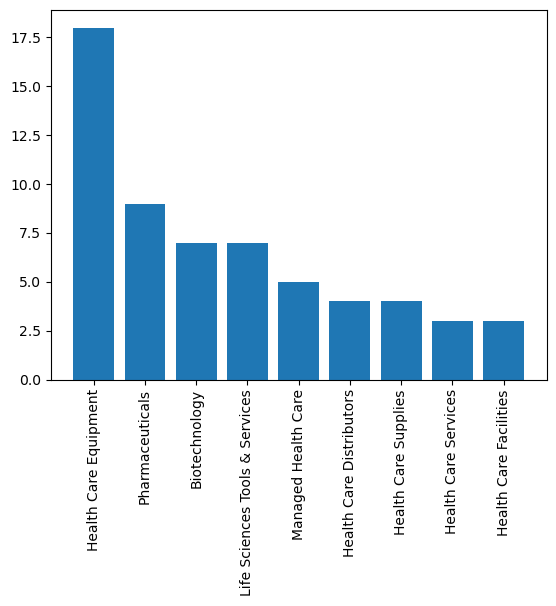

In [57]:
merged = data.merge(data1, on="Symbol")
consdiscre = merged.loc[merged["GICS_Sector"] == "Health Care", "subindustry"].value_counts().reset_index()
plt.bar(consdiscre["subindustry"], consdiscre["count"])
plt.xticks(rotation = 90)

In [ ]:
x=np.random.normal(0, 0.1, 1)